# 📊 Retail Sales Analytics

## Análisis Exploratorio de Datos (EDA) con Python

### Descripción del Proyecto

Este proyecto tiene como objetivo analizar un conjunto de datos de ventas de una tienda minorista (Superstore) para identificar patrones, tendencias y oportunidades de mejora en el negocio.

A través de técnicas de análisis exploratorio de datos (EDA), se estudian aspectos como las ventas, ganancias, productos, clientes, regiones geográficas y el impacto de los descuentos sobre la rentabilidad.

### Herramientas utilizadas

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

### Autor

**Fabian Medina**

# 1. Objetivo del Proyecto

El objetivo de este proyecto es realizar un análisis exploratorio de datos (EDA) sobre un conjunto de información de ventas de una empresa minorista.

Durante el análisis se responderán preguntas relacionadas con:

- ¿Cómo evolucionaron las ventas y las ganancias a lo largo del tiempo?
- ¿Cuáles son las categorías y productos con mejor desempeño?
- ¿Qué clientes generan mayores ingresos y ganancias?
- ¿Qué regiones presentan mejores resultados?
- ¿Cómo impactan los descuentos en la rentabilidad del negocio?

Los resultados obtenidos servirán como base para la construcción de un dashboard interactivo en Power BI.

# 2. Descripción del Dataset

El conjunto de datos utilizado corresponde a las ventas de una tienda minorista (Superstore).

Contiene información relacionada con:

- Pedidos realizados.
- Fechas de compra y envío.
- Clientes.
- Productos.
- Categorías y subcategorías.
- Ubicación geográfica.
- Ventas.
- Descuentos.
- Ganancias.

Después del proceso de limpieza, el dataset contiene aproximadamente:

- 9.994 registros.
- 25 columnas.

# 3. Importación de Librerías

In [18]:
# ==========================================================
# Importación de librerías
# ==========================================================

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Configuración para mostrar todas las columnas de pandas
pd.set_option("display.max_columns", None)

# Configuración general de gráficos
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100


# ==========================================================
# Configuración de carpetas
# ==========================================================

PROJECT_ROOT = Path.cwd()

IMAGE_FOLDER = PROJECT_ROOT / "images"

IMAGE_FOLDER.mkdir(exist_ok=True)

# 4. Carga de Datos

En esta sección se carga el dataset previamente procesado, el cual será utilizado durante todo el análisis exploratorio.

El archivo **Superstore_Clean.csv** contiene la información limpia y enriquecida con nuevas variables temporales creadas durante la fase de preparación de datos.

In [3]:
# ==========================================================
# Configuración de rutas
# ==========================================================

PROJECT_ROOT = Path.cwd()

INPUT_FILE = PROJECT_ROOT / "data" / "processed" / "Superstore_Clean.csv"

# ==========================================================
# Cargar dataset
# ==========================================================

df = pd.read_csv(INPUT_FILE)

print(f"Número de registros : {df.shape[0]}")
print(f"Número de columnas  : {df.shape[1]}")

display(df.head())

Número de registros : 9994
Número de columnas  : 25


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Noviembre,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Noviembre,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Junio,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Octubre,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Octubre,4


# 5. Verificación de la Calidad de los Datos

Antes de iniciar el análisis exploratorio, se verifica que el conjunto de datos se encuentre en condiciones adecuadas para su utilización.

Las validaciones realizadas incluyen:

- Tipos de datos.
- Valores nulos.
- Registros duplicados.
- Resumen estadístico de las variables numéricas.

In [4]:
# ==========================================================
# Información general del dataset
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
# ==========================================================
# Valores nulos por columna
# ==========================================================

df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Month Name       0
Quarter          0
dtype: int64

In [6]:
# ==========================================================
# Registros duplicados
# ==========================================================

print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


In [7]:
# ==========================================================
# Estadísticas descriptivas
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976
Year,9994.0,2015.722233,1.123555,2014.000,2015.00000,2016.0000,2017.000,2017.000
Month,9994.0,7.809686,3.284654,1.000,5.00000,9.0000,11.000,12.000
Quarter,9994.0,2.882329,1.058086,1.000,2.00000,3.0000,4.000,4.000


## Conclusiones

Después de realizar las verificaciones sobre el conjunto de datos se puede concluir lo siguiente:

- El dataset contiene **9.994 registros** y **25 variables**, proporcionando suficiente información para realizar un análisis exploratorio representativo.
- No se encontraron valores nulos en ninguna de las columnas, por lo que no fue necesario realizar imputaciones de datos.
- No existen registros duplicados, garantizando la integridad de la información utilizada durante el análisis.
- Las variables numéricas presentan rangos coherentes con un escenario de ventas minoristas, incluyendo ventas, descuentos, cantidades y ganancias.
- Se observan productos con ganancias negativas, lo que permitirá analizar posteriormente el impacto de los descuentos y otros factores sobre la rentabilidad.
- El conjunto de datos se encuentra limpio y preparado para iniciar el análisis exploratorio (EDA).

# 6. Análisis Exploratorio de Datos

En esta sección se analizan las principales variables del negocio mediante indicadores y visualizaciones que permiten comprender el comportamiento de las ventas, la rentabilidad, los productos, los clientes y la distribución geográfica.

El objetivo es identificar tendencias, oportunidades y posibles problemas que sirvan como apoyo para la toma de decisiones.

## 6.1 Análisis General de Ventas

Se inicia el análisis explorando el comportamiento de las ventas y las ganancias durante el período de estudio. Se evaluarán los principales indicadores del negocio y la evolución temporal de las ventas.

In [8]:
PROJECT_ROOT = Path.cwd()

INPUT_FILE = PROJECT_ROOT / "data" / "processed" / "Superstore_Clean.csv"

df = pd.read_csv(INPUT_FILE)

In [9]:
ventas_totales = df["Sales"].sum()
ganancias_totales = df["Profit"].sum()
ordenes = df["Order ID"].nunique()
clientes = df["Customer ID"].nunique()

print(f"Ventas Totales     : ${ventas_totales:,.2f}")
print(f"Ganancias Totales : ${ganancias_totales:,.2f}")
print(f"Órdenes           : {ordenes}")
print(f"Clientes          : {clientes}")

Ventas Totales     : $2,297,200.86
Ganancias Totales : $286,397.02
Órdenes           : 5009
Clientes          : 793


### Indicadores generales

Los indicadores muestran el volumen total de ventas, las ganancias obtenidas durante el período analizado, el número de órdenes procesadas y la cantidad de clientes únicos registrados.

Estos valores ofrecen una visión general del desempeño del negocio antes de profundizar en los análisis específicos.

### Gráfico 1 - Ventas por Año

Este gráfico muestra la evolución de las ventas durante los cuatro años analizados. Su objetivo es identificar la tendencia general del negocio y determinar si las ventas han crecido o disminuido con el tiempo.

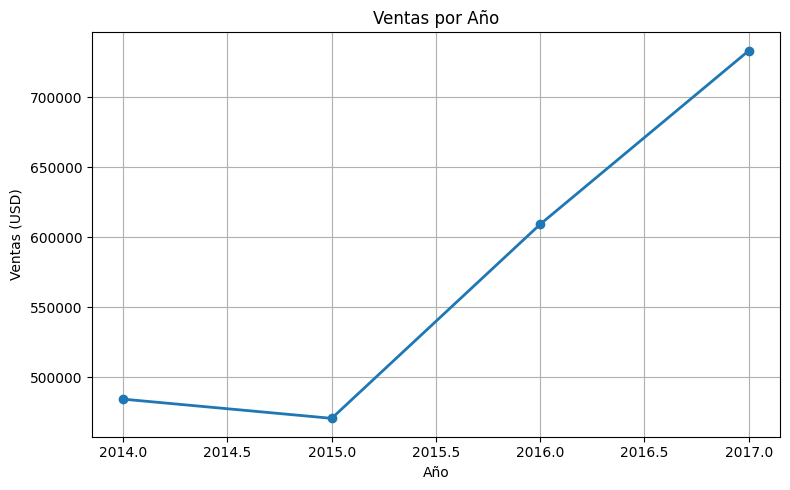

In [10]:
sales_by_year = (
    df.groupby("Year")["Sales"]
        .sum()
        .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    sales_by_year["Year"],
    sales_by_year["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Ventas por Año")
plt.xlabel("Año")
plt.ylabel("Ventas (USD)")

plt.grid(True)

plt.tight_layout()

plt.show()

### Interpretación

Las ventas muestran una tendencia de crecimiento a partir de 2015. Después de una ligera disminución entre 2014 ($484,247) y 2015 ($470,533), la empresa experimentó un incremento importante en los dos años siguientes, alcanzando $733,215 en 2017, el valor más alto del período analizado.

Entre 2015 y 2017 las ventas crecieron aproximadamente un 56%, lo que indica una expansión sostenida del negocio y una mayor capacidad para generar ingresos.

Este comportamiento sugiere que las estrategias comerciales implementadas durante los últimos años del período fueron efectivas y permitieron aumentar el volumen de ventas.

Conclusiones

Existe una clara tendencia de crecimiento de las ventas después de 2015.
2017 fue el año con el mejor desempeño comercial.
El negocio muestra señales de expansión sostenida durante el período analizado.


### Gráfico 2 - Ganancias por Año

Además del crecimiento en ventas, es importante analizar la evolución de las ganancias para determinar si el incremento en las ventas también se traduce en una mayor rentabilidad.

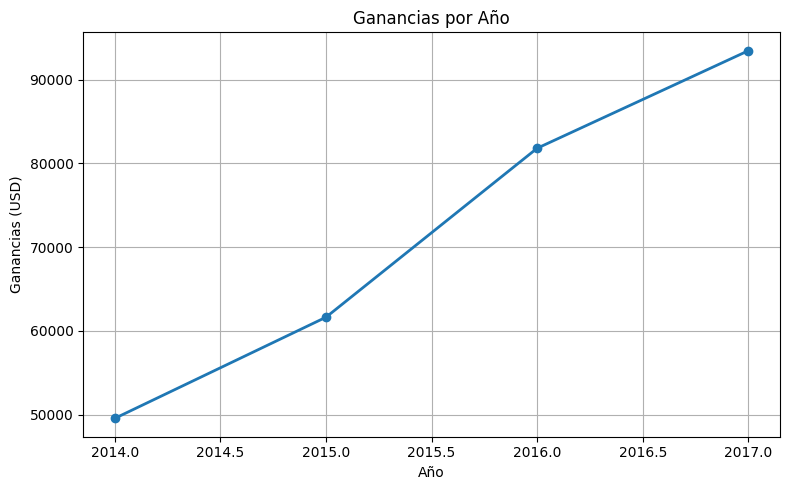

In [11]:
profit_by_year = (
    df.groupby("Year")["Profit"]
        .sum()
        .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    profit_by_year["Year"],
    profit_by_year["Profit"],
    marker="o",
    linewidth=2
)

plt.title("Ganancias por Año")
plt.xlabel("Año")
plt.ylabel("Ganancias (USD)")

plt.grid(True)

plt.tight_layout()

plt.show()

### Interpretación

Las ganancias presentan un crecimiento continuo durante todo el período analizado, pasando de $49,544 en 2014 a $93,439 en 2017.

A diferencia de las ventas, las ganancias no presentan disminuciones entre años, lo que indica que la empresa no solo vendió más, sino que también logró mantener un margen de rentabilidad favorable.

El incremento cercano al 89% en las ganancias durante cuatro años evidencia una mejora consistente en el desempeño financiero.

Conclusiones

La rentabilidad aumentó de manera sostenida entre 2014 y 2017.
El crecimiento de las ganancias fue incluso mayor que el crecimiento de las ventas.
La empresa logró mejorar sus resultados financieros sin deteriorar sus márgenes.

### Gráfico 3 - Evolución Mensual de las Ventas por Año

El análisis mensual permite identificar patrones estacionales y detectar los meses con mayor o menor actividad comercial.

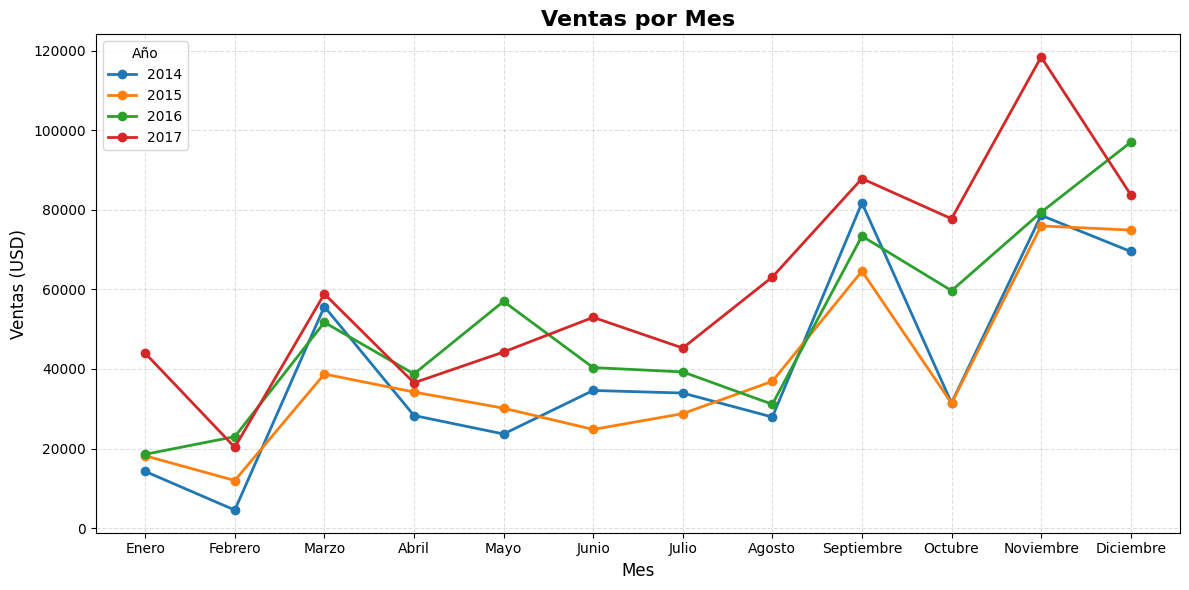

In [30]:
# ==========================================================
# Gráfico 3 - Ventas por Mes
# ==========================================================

sales_by_year_month = (
    df.groupby(["Year", "Month", "Month Name"])["Sales"]
        .sum()
        .reset_index()
        .sort_values(["Year", "Month"])
)

plt.figure(figsize=(12,6))

for year in sorted(sales_by_year_month["Year"].unique()):

    data = sales_by_year_month[
        sales_by_year_month["Year"] == year
    ]

    plt.plot(
        data["Month Name"],
        data["Sales"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title("Ventas por Mes", fontsize=16, fontweight="bold")
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Ventas (USD)", fontsize=12)

plt.legend(title="Año")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

# plt.savefig(IMAGE_FOLDER / "03_sales_by_month.png", dpi=300)

plt.show()

### Interpretación

* Las ventas muestran una tendencia creciente año tras año, siendo 2017 el mejor desempeño mensual en la mayoría de los meses.
* Se observa un patrón estacional claro, donde las ventas aumentan significativamente durante el último trimestre del año.
* Noviembre de 2017 registra el mayor volumen de ventas del período, con aproximadamente USD 118.000, seguido por diciembre de 2017 con cerca de USD 84.000.
* Los primeros meses del año (enero y febrero) presentan los niveles de ventas más bajos en todos los años analizados.
* A partir de septiembre comienza un incremento sostenido de las ventas que se mantiene hasta noviembre, evidenciando un fuerte comportamiento estacional asociado al cierre del año.

### Gráfico 4 - Ganancias Mensuales por Año

Este gráfico muestra el comportamiento de las ganancias a lo largo de los meses del año. Su análisis permite identificar patrones estacionales en la rentabilidad del negocio y comparar si los meses con mayores ventas también generan mayores ganancias.

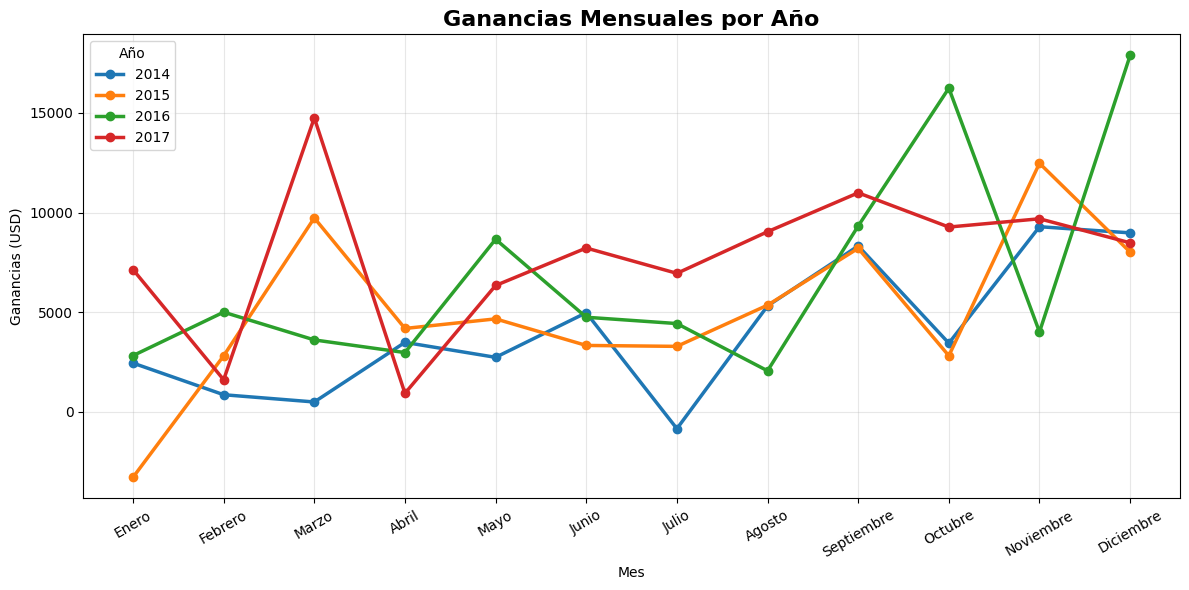

In [34]:
# ==========================================================
# Gráfico 4 - Ganancias por Mes
# ==========================================================

import matplotlib.pyplot as plt

# Agrupar ganancias por Año y Mes
profit_by_month = (
    df.groupby(["Year", "Month"])["Profit"]
        .sum()
        .reset_index()
)

# Agregar nombre del mes
months = {
    1:"Enero",2:"Febrero",3:"Marzo",4:"Abril",
    5:"Mayo",6:"Junio",7:"Julio",8:"Agosto",
    9:"Septiembre",10:"Octubre",11:"Noviembre",12:"Diciembre"
}

profit_by_month["Month Name"] = profit_by_month["Month"].map(months)

# Orden de los meses
month_order = [
    "Enero","Febrero","Marzo","Abril","Mayo","Junio",
    "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"
]

profit_by_month["Month Name"] = pd.Categorical(
    profit_by_month["Month Name"],
    categories=month_order,
    ordered=True
)

profit_by_month = profit_by_month.sort_values(["Year","Month"])

# Crear gráfico

plt.figure(figsize=(12,6))

for year in sorted(profit_by_month["Year"].unique()):
    temp = profit_by_month[profit_by_month["Year"] == year]

    plt.plot(
        temp["Month Name"],
        temp["Profit"],
        marker="o",
        markersize=6,
        linewidth=2.5,
        label=str(year)
    )

plt.title("Ganancias Mensuales por Año", fontsize=16, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Ganancias (USD)")
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.legend(title="Año")

plt.tight_layout()

### Interpretación

* En 2017 las ganancias se mantuvieron relativamente estables durante todo el año, con un máximo cercano a 15 mil USD en marzo y un cierre sólido alrededor de 9 mil USD en diciembre.
* 2016 presentó la mayor variabilidad, alcanzando sus mejores resultados en octubre (≈16 mil USD) y diciembre (≈18 mil USD), siendo este el mayor valor mensual de todo el período analizado.
* 2015 mostró un comportamiento más irregular, con pérdidas en enero y un pico de ganancias en noviembre (≈12 mil USD).
* 2014 fue el año con menor desempeño mensual, incluso registrando pérdidas en julio, aunque mostró una recuperación durante el último trimestre.

### Conclusiones del Análisis General

- Las ventas muestran una tendencia de crecimiento durante el período analizado. Después de una ligera disminución entre 2014 ($484,247) y 2015 ($470,533), la compañía experimentó un incremento significativo en 2016 ($609,206) y alcanzó su mejor desempeño en 2017 con ventas por $733,215, lo que representa un crecimiento cercano al 56% respecto a 2015.

- Las ganancias presentaron un crecimiento sostenido año tras año, pasando de $49,544 en 2014 a $93,439 en 2017. Esto indica que, además de incrementar las ventas, la empresa logró mejorar su rentabilidad durante el período analizado.

- El análisis mensual evidencia un patrón estacional en las ventas. Los meses de septiembre, noviembre y diciembre concentran los mayores ingresos en la mayoría de los años, destacándose noviembre de 2017 con aproximadamente $118,000 en ventas, mientras que enero y febrero suelen registrar los niveles más bajos de facturación.

- Las ganancias mensuales también muestran una fuerte variabilidad. El mayor valor se registró en diciembre de 2016, con aproximadamente $18,000, mientras que algunos meses, como julio de 2014 y enero de 2015, presentaron ganancias negativas, evidenciando periodos donde los costos y descuentos afectaron la rentabilidad.

- En conjunto, los resultados indican que la empresa no solo incrementó sus ventas a lo largo de los cuatro años analizados, sino que también mejoró su capacidad para generar beneficios. No obstante, la variabilidad observada en algunos meses sugiere la necesidad de analizar con mayor detalle factores como descuentos, categorías de productos y comportamiento de los clientes para identificar oportunidades de optimización.

# 6.2 Análisis por Categoría de Producto

## Objetivo

Analizar el desempeño de las principales categorías de productos para identificar cuáles generan el mayor volumen de ventas y cuáles aportan una mayor rentabilidad. Este análisis permite reconocer las categorías con mejor desempeño comercial y aquellas que representan oportunidades de mejora en la estrategia de ventas y rentabilidad.

### Gráfico 5 - Ventas por Categoría

Este gráfico muestra el total de ventas generado por cada categoría de productos, permitiendo identificar cuáles representan la mayor participación en los ingresos de la empresa.

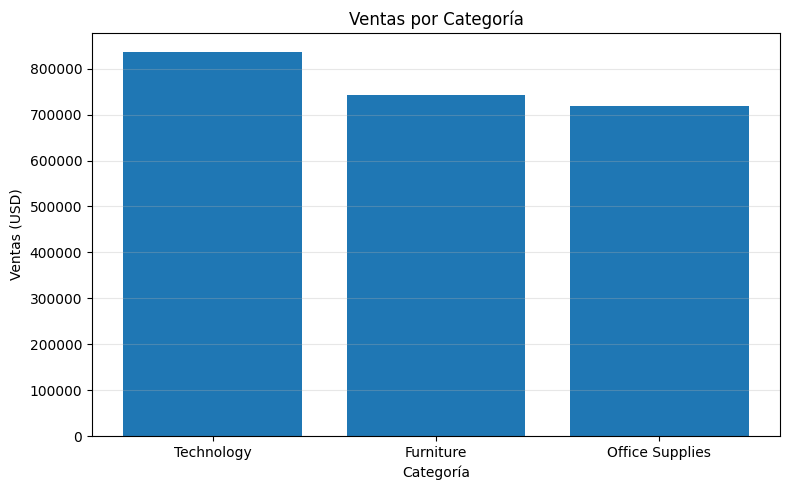

In [35]:
# ==========================================================
# Gráfico 5 - Ventas por Categoría
# ==========================================================

import matplotlib.pyplot as plt

# Agrupar ventas por categoría
sales_by_category = (
    df.groupby("Category")["Sales"]
        .sum()
        .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    sales_by_category.index,
    sales_by_category.values
)

plt.title("Ventas por Categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas (USD)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretación

El análisis de las ventas por categoría muestra que **Technology** es la categoría con el mayor volumen de ventas, alcanzando aproximadamente **836 mil USD**, lo que representa la principal fuente de ingresos de la empresa.

En segundo lugar se encuentra **Furniture**, con cerca de **742 mil USD**, seguida por **Office Supplies**, con aproximadamente **719 mil USD**. Aunque la diferencia entre estas dos últimas categorías no es muy amplia, ambas se encuentran por debajo de Technology.

Estos resultados indican que la mayor demanda del negocio se concentra en productos tecnológicos, mientras que las demás categorías mantienen una participación importante en las ventas totales.

### Gráfico 6 - Ganancias por Categoría

Además del volumen de ventas, es importante analizar qué categorías generan una mayor rentabilidad. Este gráfico compara las ganancias obtenidas por cada categoría de productos.

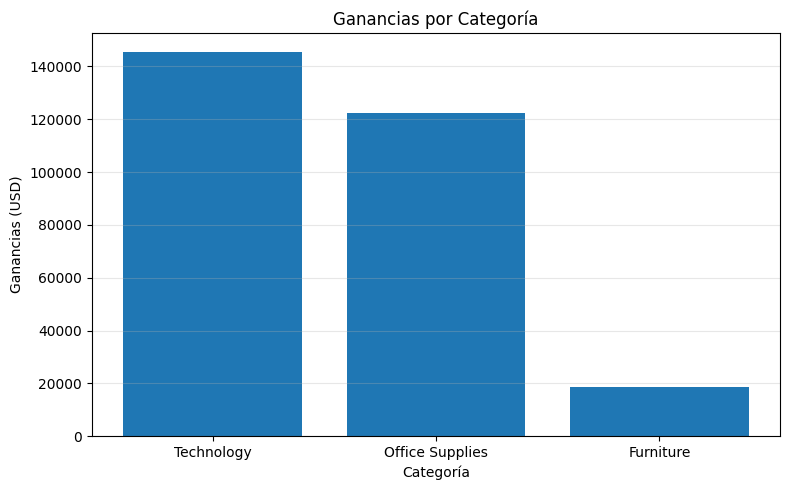

In [36]:
# ==========================================================
# Gráfico 6 - Ganancias por Categoría
# ==========================================================

import matplotlib.pyplot as plt

# Agrupar ganancias por categoría
profit_by_category = (
    df.groupby("Category")["Profit"]
        .sum()
        .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    profit_by_category.index,
    profit_by_category.values
)

plt.title("Ganancias por Categoría")
plt.xlabel("Categoría")
plt.ylabel("Ganancias (USD)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretación

El análisis de las ganancias por categoría evidencia que **Technology** no solo lidera las ventas, sino que también genera la mayor rentabilidad, con aproximadamente **145 mil USD** de ganancias.

Por su parte, **Office Supplies** ocupa el segundo lugar con cerca de **122 mil USD**, demostrando una buena relación entre ventas y rentabilidad.

En contraste, **Furniture**, a pesar de ser la segunda categoría con mayores ventas (742 mil USD), genera únicamente alrededor de **18 mil USD** de ganancias. Este comportamiento sugiere que esta categoría opera con márgenes considerablemente más bajos, posiblemente debido a descuentos frecuentes o altos costos asociados.

### Gráfico 7 - Top 10 Subcategorías por Ventas

Con el fin de profundizar en el análisis de las categorías de productos, en este gráfico se identifican las **10 subcategorías con mayor volumen de ventas**. Este análisis permite conocer cuáles son los productos que generan la mayor parte de los ingresos y detectar oportunidades para fortalecer las estrategias comerciales sobre las líneas más demandadas.

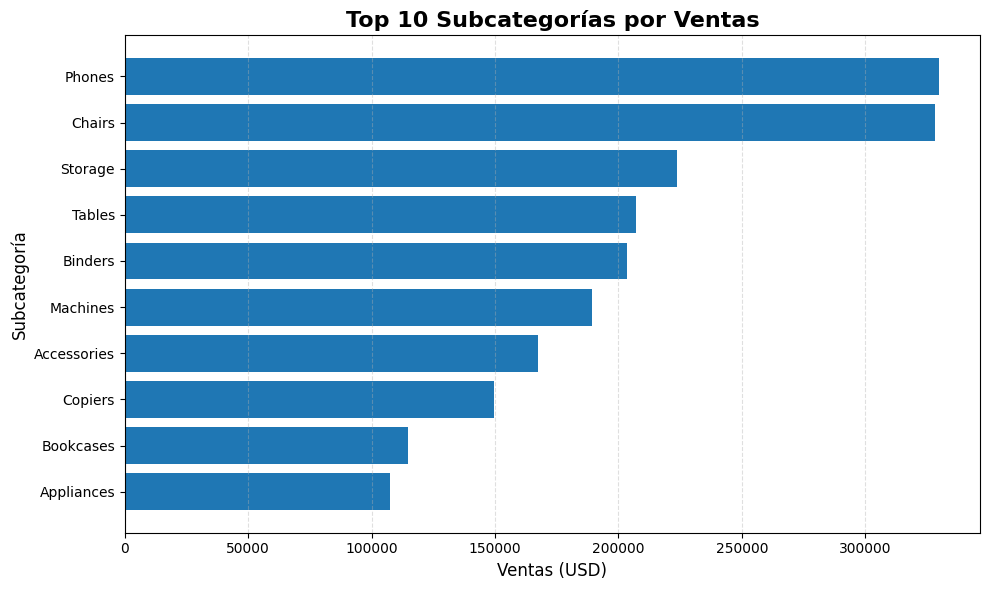

In [37]:
# ==========================================================
# Gráfico 7 - Top 10 Subcategorías por Ventas
# ==========================================================

import matplotlib.pyplot as plt

# Agrupar ventas por subcategoría
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    subcategory_sales.index,
    subcategory_sales.values
)

plt.title(
    "Top 10 Subcategorías por Ventas",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Ventas (USD)", fontsize=12)
plt.ylabel("Subcategoría", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Interpretación

Las ventas se concentran principalmente en un reducido grupo de subcategorías. **Phones** lidera el ranking con **USD 330,007**, seguida muy de cerca por **Chairs** con **USD 328,449**, lo que evidencia una fuerte demanda tanto de productos tecnológicos como de mobiliario.

En un segundo nivel se encuentran **Storage** (USD 223,844), **Tables** (USD 206,966) y **Binders** (USD 203,413), todas superando los USD 200,000 en ventas.

Las subcategorías **Machines** (USD 189,239), **Accessories** (USD 167,380) y **Copiers** (USD 149,528) también representan una parte importante de los ingresos, mientras que **Bookcases** (USD 114,880) y **Appliances** (USD 107,532) completan el Top 10.

En conjunto, el gráfico evidencia que una parte considerable de las ventas de la empresa se concentra en pocas subcategorías, lo que permite identificar claramente cuáles deben ser priorizadas en estrategias comerciales, campañas de marketing y gestión de inventario.

### Gráfico 8 - Top 10 Productos por Ventas

Una vez identificadas las subcategorías con mayor volumen de ventas, resulta conveniente profundizar el análisis hasta el nivel de producto. En este gráfico se presentan los **10 productos con mayores ventas**, permitiendo identificar cuáles son los artículos que generan la mayor parte de los ingresos de la empresa y que representan los principales impulsores del negocio.

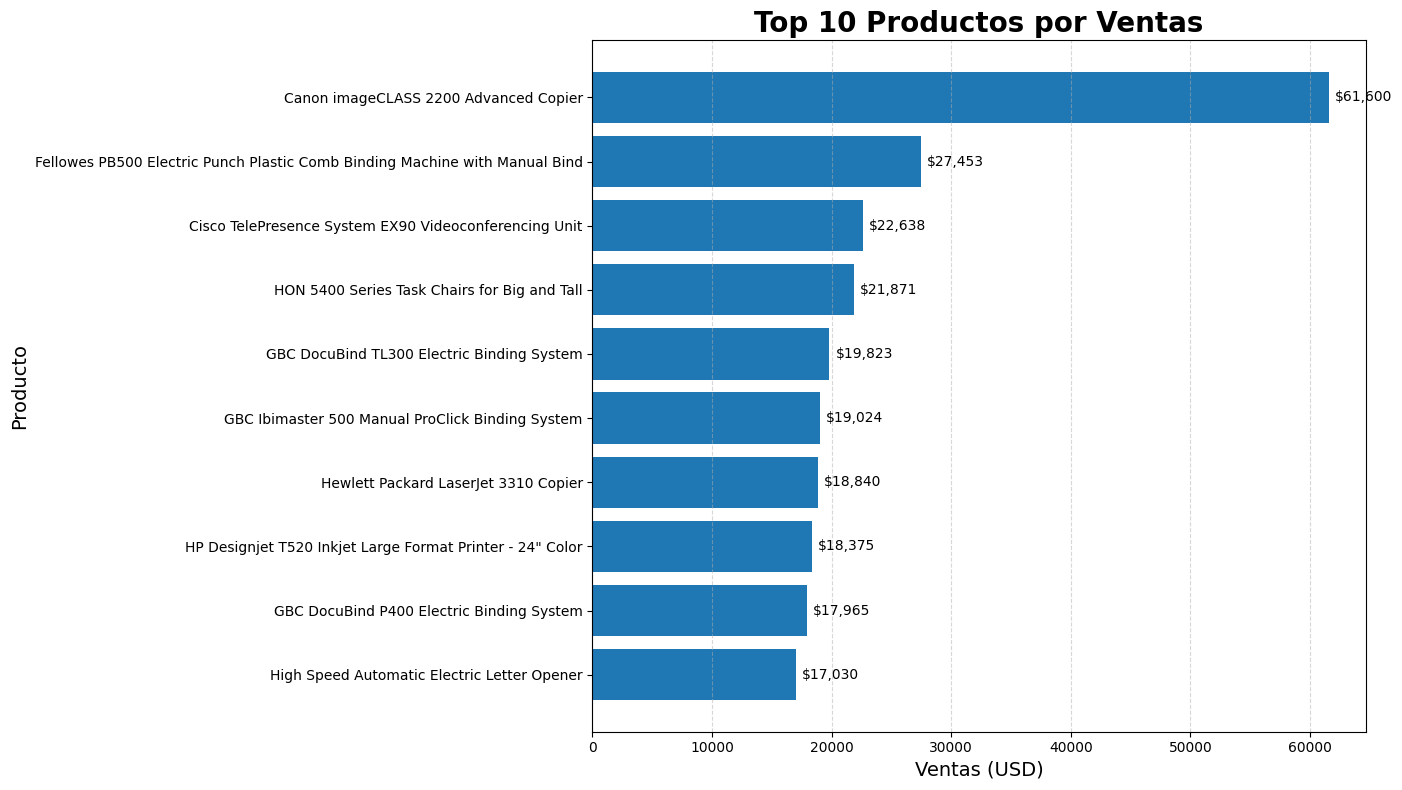

In [38]:
# ==========================================================
# Gráfico 8 - Top 10 Productos por Ventas
# ==========================================================

import matplotlib.pyplot as plt

# Agrupar ventas por producto
top_products_sales = (
    df.groupby("Product Name")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .sort_values()
)

# Crear gráfico
plt.figure(figsize=(14, 8))

bars = plt.barh(
    top_products_sales.index,
    top_products_sales.values
)

# Agregar etiquetas de valor
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Productos por Ventas",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Ventas (USD)", fontsize=14)
plt.ylabel("Producto", fontsize=14)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

# Guardar imagen (opcional)
# plt.savefig("images/top10_products_sales.png", dpi=300)

plt.show()

### Interpretación

El producto con mayor volumen de ventas es **Canon imageCLASS 2200 Advanced Copier**, alcanzando aproximadamente **USD 61,600**, una cifra muy superior al resto de productos del ranking.

En segundo lugar se encuentra **Fellowes PB500 Electric Punch Plastic Comb Binding Machine** con **USD 27,453**, seguida por **Cisco TelePresence System EX90 Videoconferencing Unit** con **USD 22,638**.

El resto de productos presenta ventas entre **USD 17,000 y USD 22,000**, destacándose artículos relacionados con equipos de oficina, impresoras, sistemas de encuadernación y mobiliario empresarial.

La diferencia entre el primer producto y el resto del Top 10 demuestra que algunos artículos tienen un peso considerable dentro de los ingresos totales de la empresa, por lo que mantener su disponibilidad y fortalecer su estrategia comercial puede tener un impacto significativo en las ventas.

### Conclusiones del Análisis por Categoría de Producto

- **Technology** se consolida como la categoría con mejor desempeño, liderando tanto las ventas como la rentabilidad.

- Las ventas se concentran en un número reducido de subcategorías, destacándose **Phones**, **Chairs** y **Storage**, lo que evidencia una alta demanda de estos productos.

- A nivel de producto, el **Canon imageCLASS 2200 Advanced Copier** sobresale como el artículo con mayor volumen de ventas, convirtiéndose en uno de los principales impulsores de los ingresos de la empresa.

- Los resultados muestran que el análisis a nivel de producto complementa la información obtenida por categorías y subcategorías, permitiendo identificar con mayor precisión cuáles artículos representan las mejores oportunidades comerciales y requieren una adecuada gestión de inventario y abastecimiento.

## 6.3 Análisis Geográfico

### Objetivo

Analizar el desempeño comercial de las diferentes regiones para identificar cuáles generan un mayor volumen de ventas y cuáles aportan una mayor rentabilidad al negocio. Este análisis permite reconocer los mercados más fuertes de la empresa y detectar oportunidades de crecimiento en aquellas regiones con menor desempeño.

### Gráfico 9 - Ventas por Región

Este gráfico muestra el total de ventas generado en cada región. Comparar las ventas entre regiones permite identificar dónde se concentra la mayor actividad comercial y cuáles mercados representan una mayor participación dentro de la empresa.


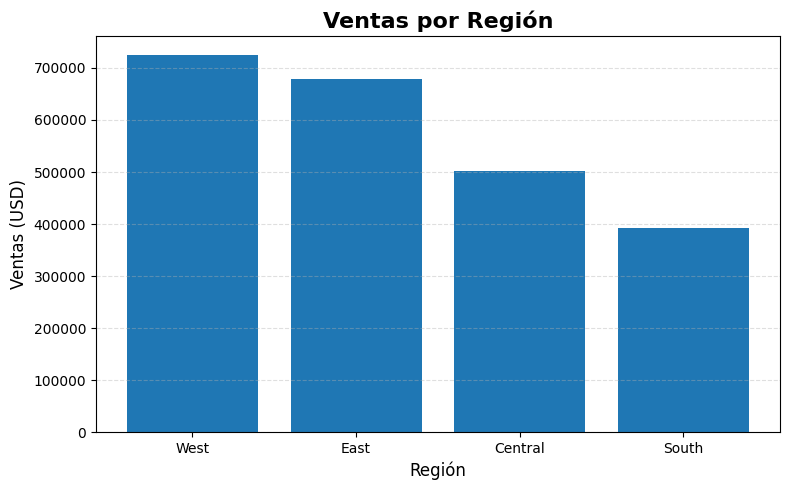

In [ ]:
# ==========================================================
# Gráfico 9 - Ventas por Región
# ==========================================================

sales_by_region = (
    df.groupby("Region")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    sales_by_region["Region"],
    sales_by_region["Sales"]
)

plt.title("Ventas por Región")
plt.xlabel("Región")
plt.ylabel("Ventas")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    IMAGE_FOLDER / "sales_by_region.png",
    dpi=300
)

plt.show()

In [44]:
sales_by_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

### Interpretación

La región **West** registró el mayor volumen de ventas, alcanzando aproximadamente **USD 725,458**, lo que la convierte en el mercado con mayor participación dentro de la empresa.

En segundo lugar se ubicó la región **East** con ventas cercanas a **USD 678,781**, mostrando un desempeño muy competitivo y una diferencia aproximada de **USD 46,677** respecto a la región líder.

Por su parte, **Central** obtuvo ventas por **USD 501,240**, mientras que **South** presentó el menor volumen de ventas con **USD 391,722**, ubicándose aproximadamente **USD 333,736** por debajo de la región West.

Estos resultados evidencian una clara concentración de las ventas en las regiones **West** y **East**, las cuales representan los principales mercados para la compañía.

### Gráfico 10 - Ganancias por Región

Después de analizar el volumen de ventas por región, es importante evaluar qué tan rentables son dichos mercados. Este gráfico presenta las ganancias obtenidas en cada región, permitiendo identificar aquellas que no solo venden más, sino que también generan un mayor beneficio para la empresa.

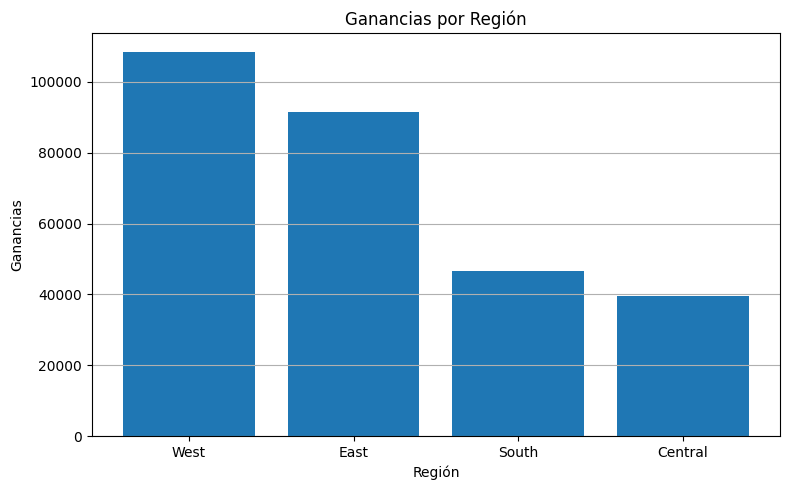

In [41]:
# ==========================================================
# Gráfico 10 - Ganancias por Región
# ==========================================================

profit_by_region = (
    df.groupby("Region")["Profit"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    profit_by_region["Region"],
    profit_by_region["Profit"]
)

plt.title("Ganancias por Región")
plt.xlabel("Región")
plt.ylabel("Ganancias")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    IMAGE_FOLDER / "profit_by_region.png",
    dpi=300
)

plt.show()

In [43]:
profit_by_region

,Region,Profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


### Interpretación

La región **West** obtuvo la mayor ganancia del período, alcanzando aproximadamente **USD 108,418**, lo que confirma que además de ser la región con mayores ventas, también es la más rentable para la empresa.

En segundo lugar se ubicó la región **East**, con una ganancia cercana a **USD 91,523**, manteniendo una relación consistente con su alto volumen de ventas.

Aunque la región **Central** registró ventas superiores a **USD 501,240**, sus ganancias fueron de apenas **USD 39,706**, siendo superada por la región **South**, que obtuvo una ganancia de **USD 46,749** pese a registrar el menor volumen de ventas (**USD 391,722**).

Estos resultados indican que un mayor nivel de ventas no garantiza necesariamente una mayor rentabilidad. La región **South** demuestra un mejor desempeño en términos de beneficio generado respecto a sus ventas, mientras que **Central** podría estar siendo afectada por factores como mayores descuentos, costos operativos o una mezcla de productos con menor margen de ganancia.

### Conclusiones

- La región **West** se consolida como el mercado más importante para la empresa, liderando tanto las ventas (**USD 725,458**) como las ganancias (**USD 108,418**).

- La región **East** ocupa el segundo lugar tanto en ventas (**USD 678,781**) como en ganancias (**USD 91,523**), evidenciando un desempeño comercial sólido y consistente.

- Aunque **Central** supera a **South** en ventas (**USD 501,240** frente a **USD 391,722**), genera una menor ganancia (**USD 39,706** frente a **USD 46,749**), lo que sugiere una rentabilidad inferior.

- Los resultados demuestran que el análisis geográfico no debe centrarse únicamente en las ventas, sino también en la rentabilidad obtenida por cada región, ya que esto permite identificar oportunidades para optimizar estrategias comerciales, revisar políticas de descuentos y mejorar el margen de beneficio en aquellas regiones con menor desempeño financiero.

## 6.4 Análisis de Clientes

### Objetivo

Analizar el comportamiento de los diferentes segmentos de clientes para identificar cuáles generan un mayor volumen de ventas y una mayor rentabilidad para la empresa. Este análisis permite comprender la contribución de cada segmento al desempeño del negocio y orientar estrategias comerciales hacia los grupos de clientes más valiosos.

### Gráfico 11 - Ventas por Segmento

En este gráfico se presenta el total de ventas generado por cada segmento de clientes. El objetivo es identificar cuáles grupos aportan una mayor participación en los ingresos de la empresa y comprender cómo se distribuyen las ventas entre los diferentes perfiles de clientes.

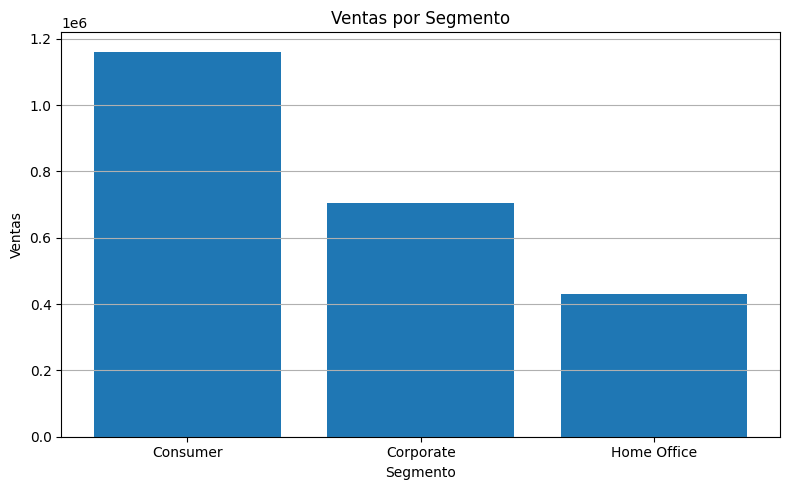

In [45]:
# ==========================================================
# Gráfico 11 - Ventas por Segmento
# ==========================================================

sales_by_segment = (
    df.groupby("Segment")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    sales_by_segment["Segment"],
    sales_by_segment["Sales"]
)

plt.title("Ventas por Segmento")
plt.xlabel("Segmento")
plt.ylabel("Ventas")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    IMAGE_FOLDER / "sales_by_segment.png",
    dpi=300
)

plt.show()

In [46]:
sales_by_segment

,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


### Interpretación

El segmento **Consumer** registró el mayor volumen de ventas, alcanzando aproximadamente **USD 1.16 millones**, lo que representa el principal mercado para la empresa y evidencia que los clientes individuales constituyen la mayor fuente de ingresos.

En segundo lugar se ubicó el segmento **Corporate**, con ventas cercanas a **USD 706 mil**, equivalente a cerca del **61 %** de las ventas generadas por el segmento Consumer.

Por su parte, el segmento **Home Office** obtuvo ventas aproximadas de **USD 430 mil**, siendo el grupo con menor participación dentro del negocio.

Los resultados muestran una clara concentración de las ventas en el segmento **Consumer**, lo que sugiere que las estrategias comerciales de la empresa están principalmente orientadas hacia clientes particulares. Sin embargo, el análisis de las ganancias permitirá determinar si este mayor volumen de ventas también se traduce en una mayor rentabilidad para la organización.

### Gráfico 12 - Ganancias por Segmento

Después de conocer qué segmentos generan el mayor volumen de ventas, es necesario analizar la rentabilidad obtenida en cada uno de ellos. Este gráfico presenta las ganancias acumuladas por segmento de clientes, permitiendo identificar cuáles contribuyen en mayor medida a los beneficios de la empresa y evaluar si un mayor nivel de ventas se traduce en una mayor rentabilidad.

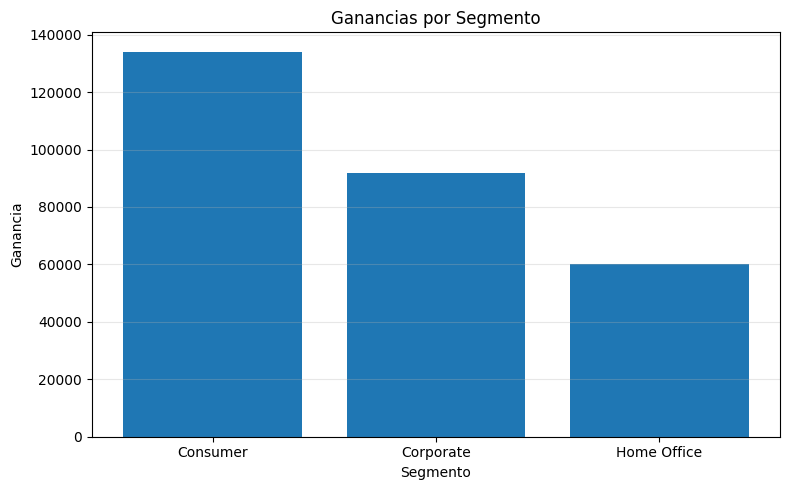

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


In [48]:
# ==========================================================
# Gráfico 12 - Ganancias por Segmento
# ==========================================================

profit_by_segment = (
    df.groupby("Segment")["Profit"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    profit_by_segment["Segment"],
    profit_by_segment["Profit"]
)

plt.title("Ganancias por Segmento")
plt.xlabel("Segmento")
plt.ylabel("Ganancia")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_FOLDER / "profit_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

profit_by_segment

### Interpretación

El segmento **Consumer** obtuvo la mayor ganancia, alcanzando aproximadamente **USD 134,119**, lo que confirma que además de generar el mayor volumen de ventas, también es el segmento más rentable para la empresa.

El segmento **Corporate** ocupó el segundo lugar con una ganancia cercana a **USD 91,979**, manteniendo una relación consistente con su nivel de ventas (**USD 706 mil**).

Por su parte, el segmento **Home Office** registró una ganancia aproximada de **USD 60,299**, siendo el segmento con menor participación tanto en ventas como en rentabilidad.

En general, los resultados muestran una correspondencia entre el volumen de ventas y las ganancias obtenidas, indicando que los segmentos que generan mayores ingresos también aportan una mayor rentabilidad al negocio.

### Conclusiones

- El segmento **Consumer** representa el mercado más importante para la empresa, liderando tanto las ventas (**USD 1.16 millones**) como las ganancias (**USD 134,119**).

- El segmento **Corporate** se consolida como el segundo segmento con mejor desempeño, registrando ventas cercanas a **USD 706 mil** y ganancias por **USD 91,979**, lo que evidencia una contribución significativa al negocio.

- El segmento **Home Office** presentó el menor volumen de ventas (**USD 430 mil**) y la menor ganancia (**USD 60,299**), lo que indica una participación más reducida dentro del mercado.

- A diferencia del análisis geográfico, donde se observaron diferencias entre ventas y rentabilidad, en el análisis por segmentos existe una relación consistente entre ambos indicadores. Los segmentos con mayores ventas también son los que generan mayores ganancias, lo que refleja una estructura comercial equilibrada y una adecuada rentabilidad por tipo de cliente.

# 7. Conclusiones Generales

El análisis exploratorio de datos permitió comprender el comportamiento de las ventas y la rentabilidad de la empresa desde diferentes perspectivas: temporal, categorías de productos, regiones geográficas y segmentos de clientes.

Los principales hallazgos obtenidos fueron los siguientes:

- Durante el período analizado se observa una tendencia de crecimiento tanto en las ventas como en las ganancias, alcanzando los mejores resultados en el año **2017**, lo que evidencia un incremento sostenido de la actividad comercial.

- El comportamiento mensual muestra una marcada estacionalidad, con un aumento significativo de las ventas durante los últimos meses del año, especialmente entre **septiembre y diciembre**, siendo **noviembre** el mes con mayor volumen de ventas y ganancias.

- La categoría **Technology** se consolidó como la línea de negocio con mejor desempeño, liderando tanto las ventas como la rentabilidad. Dentro de ella destacan subcategorías como **Phones** y varios equipos tecnológicos que generan una parte importante de los ingresos de la empresa.

- El análisis a nivel de producto permitió identificar que el **Canon imageCLASS 2200 Advanced Copier** es el artículo con mayor volumen de ventas, convirtiéndose en uno de los productos más importantes para el negocio.

- Desde el punto de vista geográfico, la región **West** registró el mejor desempeño, alcanzando aproximadamente **USD 725,458** en ventas y **USD 108,418** en ganancias. Por el contrario, se identificó un hallazgo relevante en la región **Central**, que aunque registró mayores ventas que **South**, obtuvo una menor ganancia, lo que podría estar asociado a descuentos más altos, costos operativos o una combinación de productos con menores márgenes de beneficio.

- En cuanto a los clientes, el segmento **Consumer** representa el principal mercado de la empresa, generando aproximadamente **USD 1.16 millones** en ventas y **USD 134,119** en ganancias. Además, se observó una relación consistente entre ventas y rentabilidad para los tres segmentos analizados.

En conjunto, los resultados muestran que el negocio mantiene un crecimiento sostenido y que la mayor parte de sus ingresos y beneficios se concentra en un número reducido de categorías, productos, regiones y segmentos de clientes. Estos hallazgos proporcionan información valiosa para orientar futuras estrategias comerciales, optimizar la asignación de recursos y fortalecer la toma de decisiones basada en datos.

# 8. Recomendaciones de Negocio

Con base en los resultados obtenidos durante el análisis exploratorio, se plantean las siguientes recomendaciones orientadas a fortalecer el desempeño comercial y la rentabilidad de la empresa.

### 1. Fortalecer la inversión en la categoría Technology

La categoría **Technology** lidera tanto las ventas como las ganancias, por lo que representa una de las principales fuentes de ingresos de la empresa. Se recomienda priorizar estrategias comerciales sobre esta categoría, incrementar la disponibilidad de inventario y desarrollar campañas de marketing enfocadas en sus productos más rentables.

---

### 2. Potenciar las subcategorías y productos con mayor desempeño

El análisis permitió identificar subcategorías y productos que concentran una parte importante de las ventas y las ganancias, como **Phones** y el **Canon imageCLASS 2200 Advanced Copier**. Promocionar estos productos mediante campañas, ventas cruzadas o paquetes comerciales puede contribuir a incrementar los ingresos.

---

### 3. Analizar la rentabilidad de la región Central

Aunque la región **Central** registra un volumen de ventas superior al de **South**, genera una menor ganancia. Se recomienda realizar un análisis más detallado de factores como descuentos aplicados, costos logísticos, margen por producto y comportamiento de los clientes para identificar oportunidades de mejora.

---

### 4. Mantener y fortalecer el segmento Consumer

El segmento **Consumer** representa el mayor volumen de ventas y ganancias para la empresa. Diseñar estrategias de fidelización, programas de beneficios y campañas personalizadas puede contribuir a mantener este segmento como el principal motor del negocio.

---

### 5. Aprovechar la estacionalidad de las ventas

El análisis temporal muestra un incremento significativo de las ventas durante los últimos meses del año, especialmente entre septiembre y diciembre. Planificar inventarios, campañas promocionales y recursos logísticos con anticipación permitirá aprovechar esta temporada de alta demanda y mejorar la experiencia del cliente.

---

### 6. Incorporar indicadores de rentabilidad en la toma de decisiones

Los resultados evidencian que un mayor volumen de ventas no siempre implica una mayor rentabilidad. Por ello, se recomienda complementar el seguimiento de ventas con indicadores como margen de ganancia, utilidad por producto, utilidad por región y rentabilidad por cliente para obtener una visión más completa del desempeño del negocio.

# 9. Trabajo Futuro

Este proyecto corresponde a un Análisis Exploratorio de Datos (EDA) desarrollado utilizando Python y las principales bibliotecas para análisis y visualización de datos.

Como continuación de este trabajo, se propone desarrollar una segunda versión del proyecto incorporando herramientas de Business Intelligence y bases de datos, con el objetivo de construir una solución más cercana a un entorno empresarial.

Las principales mejoras contempladas son:

- Almacenar la información en una base de datos SQL para realizar consultas mediante SQL.
- Automatizar el proceso de extracción y transformación de datos.
- Desarrollar un dashboard interactivo en Power BI con indicadores clave (KPIs).
- Implementar filtros dinámicos por año, región, categoría, segmento y producto.
- Incorporar métricas de negocio como margen de ganancia, ticket promedio, crecimiento interanual y participación por categoría.
- Comparar el desempeño de ventas y ganancias mediante visualizaciones interactivas.
- Publicar el dashboard y el código fuente en GitHub como parte del portafolio profesional.

Este proyecto constituye la primera etapa de un flujo completo de análisis de datos que integra Python para el procesamiento de datos, SQL para la gestión de información y Power BI para la visualización y comunicación de resultados.

# 10. Tecnologías Utilizadas

Durante el desarrollo de este proyecto se emplearon diferentes herramientas y bibliotecas para la limpieza, transformación, análisis y visualización de los datos.

| Tecnología | Descripción | Uso en el proyecto |
|------------|-------------|--------------------|
| 🐍 **Python** | Lenguaje de programación | Desarrollo completo del análisis de datos. |
| 🐼 **Pandas** | Biblioteca para manipulación de datos | Limpieza, transformación, agregaciones y análisis del dataset. |
| 🔢 **NumPy** | Computación numérica | Operaciones matemáticas y manejo eficiente de arreglos. |
| 📊 **Matplotlib** | Visualización de datos | Creación de gráficos estadísticos y comparativos. |
| 📓 **Jupyter Notebook** | Entorno interactivo | Documentación y desarrollo paso a paso del análisis. |
| 📁 **CSV** | Formato de almacenamiento | Fuente de datos utilizada para el análisis. |
| 🔀 **Git** | Control de versiones | Seguimiento y gestión de cambios del proyecto. |
| 🌐 **GitHub** | Repositorio de código | Publicación del proyecto y portafolio profesional. |

---

## Habilidades Demostradas

A través de este proyecto se aplicaron las siguientes competencias en análisis de datos:

- Limpieza y preparación de datos (Data Cleaning)
- Transformación y manipulación de datos
- Análisis Exploratorio de Datos (EDA)
- Estadística descriptiva
- Identificación de tendencias y patrones
- Creación de visualizaciones efectivas
- Interpretación de resultados
- Generación de recomendaciones de negocio
- Documentación técnica utilizando Markdown
- Desarrollo de proyectos reproducibles en Python

---

## Resultado Final

Este proyecto representa un flujo completo de **Análisis Exploratorio de Datos (EDA)** utilizando Python, desde la carga y limpieza de la información hasta la generación de visualizaciones, conclusiones y recomendaciones de negocio.

La siguiente etapa consistirá en transformar este análisis en una solución de Business Intelligence integrando **SQL**, **Power BI** y procesos automatizados de actualización de datos.